In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("happy_merged.csv", skiprows=15)

print(df.head())

          Date/Time  100m_N Avg [m/s]  100m_S Avg [m/s]  80m Avg [m/s]  \
0  01-12-2018 00:00            10.654            10.809          5.182   
1  01-12-2018 00:10            10.531            10.688          5.334   
2  01-12-2018 00:20             9.976            10.110          5.319   
3  01-12-2018 00:30             9.617             9.735          5.319   
4  01-12-2018 00:40             9.001             9.112          5.363   

   50m Avg [m/s]  20m Avg [m/s]  10m Avg [m/s]  Pressure 5m [mbar]  \
0          7.096          4.852            NaN              1012.2   
1          7.415          4.953            NaN              1012.1   
2          7.398          4.796            NaN              1012.2   
3          7.430          4.749            NaN              1012.1   
4          7.344          4.833            NaN              1012.0   

   98m WV [?]  78m WV [?]  48m WV [?]  Temp 5m [?C]  Hum 5m  
0        52.0        45.0        29.5          22.5    46.5  
1        5

In [14]:
print(df.columns)

Index(['Date/Time', '100m_N Avg [m/s]', '100m_S Avg [m/s]', '80m Avg [m/s]',
       '50m Avg [m/s]', '20m Avg [m/s]', '10m Avg [m/s]', 'Pressure 5m [mbar]',
       '98m WV [?]', '78m WV [?]', '48m WV [?]', 'Temp 5m [?C]', 'Hum 5m'],
      dtype='object')


In [15]:
df = df.dropna()

print(df.shape)

(20233, 13)


In [16]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

print(corr_matrix)

                    100m_N Avg [m/s]  100m_S Avg [m/s]  80m Avg [m/s]  \
100m_N Avg [m/s]            1.000000          0.995419       0.976676   
100m_S Avg [m/s]            0.995419          1.000000       0.965084   
80m Avg [m/s]               0.976676          0.965084       1.000000   
50m Avg [m/s]               0.924906          0.915601       0.965999   
20m Avg [m/s]               0.822352          0.816192       0.873057   
10m Avg [m/s]               0.778215          0.772702       0.829159   
Pressure 5m [mbar]         -0.426898         -0.424686      -0.444622   
98m WV [?]                  0.053111          0.053904       0.065586   
78m WV [?]                  0.045456          0.061554       0.014305   
48m WV [?]                  0.043253          0.060078       0.007405   
Temp 5m [?C]                0.162344          0.167931       0.196527   
Hum 5m                      0.208640          0.204081       0.250971   

                    50m Avg [m/s]  20m Avg [m/s]  

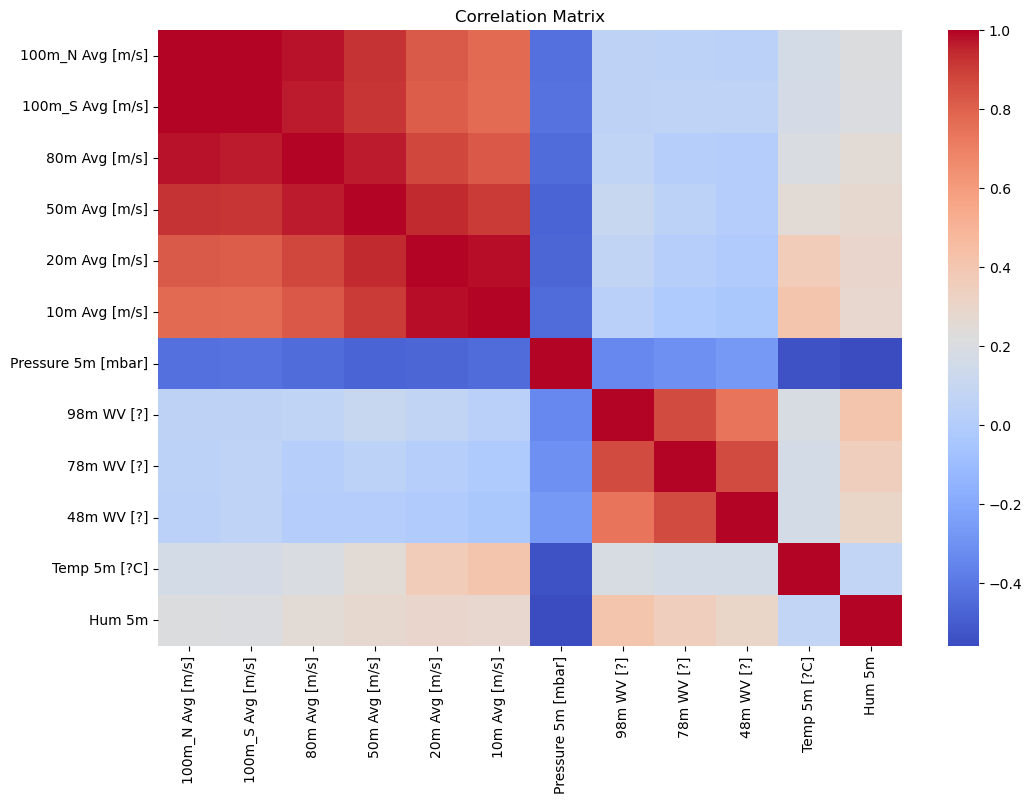

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [18]:
print(
    corr_matrix['100m_N Avg [m/s]']
    .sort_values(ascending=False)
)

100m_N Avg [m/s]      1.000000
100m_S Avg [m/s]      0.995419
80m Avg [m/s]         0.976676
50m Avg [m/s]         0.924906
20m Avg [m/s]         0.822352
10m Avg [m/s]         0.778215
Hum 5m                0.208640
Temp 5m [?C]          0.162344
98m WV [?]            0.053111
78m WV [?]            0.045456
48m WV [?]            0.043253
Pressure 5m [mbar]   -0.426898
Name: 100m_N Avg [m/s], dtype: float64


In [19]:
X = df[['50m Avg [m/s]']]

y = df['100m_N Avg [m/s]']

In [20]:
print(df.columns.tolist())

['Date/Time', '100m_N Avg [m/s]', '100m_S Avg [m/s]', '80m Avg [m/s]', '50m Avg [m/s]', '20m Avg [m/s]', '10m Avg [m/s]', 'Pressure 5m [mbar]', '98m WV [?]', '78m WV [?]', '48m WV [?]', 'Temp 5m [?C]', 'Hum 5m']


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (14163, 1)
Testing Shape: (6070, 1)


In [22]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

print("Model trained successfully")

Model trained successfully


In [24]:
y_pred = model.predict(X_test_poly)

print(y_pred[:5])

[ 5.18599732 12.35222761  6.81241555  5.62447428  6.93629884]


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("R2 Score =", r2)

MAE = 0.8455513629715515
MSE = 1.2858847618717242
R2 Score = 0.8589219347952771


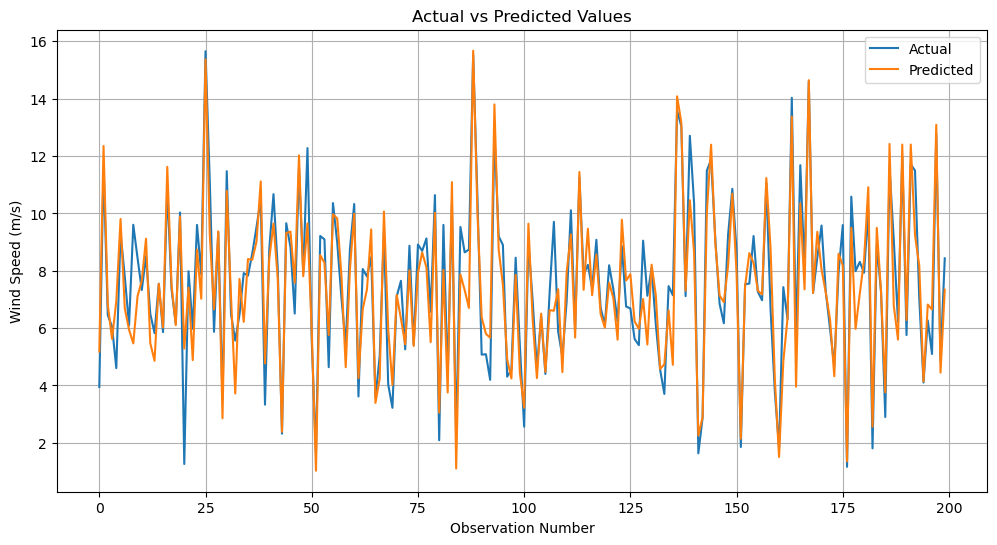

In [26]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')

plt.title('Actual vs Predicted Values')
plt.xlabel('Observation Number')
plt.ylabel('Wind Speed (m/s)')

plt.legend()
plt.grid(True)

plt.show()

In [27]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0    3.950   5.185997
1   11.662  12.352228
2    6.450   6.812416
3    6.055   5.624474
4    4.607   6.936299
5    9.314   9.805319
6    7.795   6.691591
7    6.094   5.945874
8    9.604   5.467631
9    8.447   7.109895
10   7.329   7.660079
11   8.508   9.120988
12   6.501   5.475656
13   5.827   4.863490
14   7.548   7.546784
15   5.861   6.024217
16  10.895  11.624048
17   7.356   7.506022
18   6.143   6.106976
19  10.033   9.892366
